In [4]:
!ls /content

1x1-clips-angles.csv  3x3-clips-angles.csv     bulge4-clips-angles.csv
1x2-clips-angles.csv  3x4-clips-angles.csv     bulge5-clips-angles.csv
1x3-clips-angles.csv  3x5-clips-angles.csv     hairpin3-clips-angles.csv
1x4-clips-angles.csv  4x4-clips-angles.csv     hairpin4-clips-angles.csv
1x5-clips-angles.csv  4x5-clips-angles.csv     hairpin5-clips-angles.csv
2x2-clips-angles.csv  5x5-clips-angles.csv     hairpin6-clips-angles.csv
2x3-clips-angles.csv  bulge1-clips-angles.csv  hairpin7-clips-angles.csv
2x4-clips-angles.csv  bulge2-clips-angles.csv  sample_data
2x5-clips-angles.csv  bulge3-clips-angles.csv


In [5]:
#import dataset
import pandas as pd
import glob
import os

data_dir = "/content"

all_files = glob.glob(os.path.join(data_dir, "*-clips-angles.csv"))
print("Files found:", len(all_files))
print(all_files[:5])

dfs = [pd.read_csv(f) for f in all_files]
data = pd.concat(dfs, ignore_index=True)

print("Combined dataset shape:", data.shape)
data.head()

print(data.shape)
data.head()

Files found: 25
['/content/bulge3-clips-angles.csv', '/content/hairpin6-clips-angles.csv', '/content/1x3-clips-angles.csv', '/content/bulge2-clips-angles.csv', '/content/hairpin7-clips-angles.csv']
Combined dataset shape: (201376, 87)
(201376, 87)


,Motifname,Motifseq,bb_alpha_mean,bb_alpha_median,bb_alpha_std,bb_alpha_range,bb_alpha_skewness,bb_alpha_kurtosis,bb_beta_mean,bb_beta_median,...,sugar_nu4_range,sugar_nu4_skewness,sugar_nu4_kurtosis,sugar_nu5_mean,sugar_nu5_median,sugar_nu5_std,sugar_nu5_range,sugar_nu5_skewness,sugar_nu5_kurtosis,Label
0,8WIF_GUGACCGCGGC_a305_1,CGGCGUGACCG,-0.773818,-1.155,1.212735,5.142,1.538282,2.565614,0.861000,2.890,...,1.031,2.769072,5.847912,0.343455,0.366,0.106813,0.409,-2.250063,4.099819,bulge3-clips
1,8WIF_GUCAUCACGGU_a1181_1,UGGCGUCAUCA,-1.109091,-1.061,0.892418,3.338,-0.288316,-0.077690,0.685455,2.698,...,1.132,1.638282,0.706753,0.305273,0.376,0.174644,0.520,-1.576432,0.637812,bulge3-clips
2,8WIF_GGGGAGCCCUG_a755_1,GGGGAGCGUCC,-0.854273,-1.092,1.285731,5.013,2.019228,3.406327,1.820364,2.915,...,0.121,-0.717149,0.030280,0.387818,0.386,0.041505,0.159,0.283109,-0.090454,bulge3-clips
3,8WID_GUCAUCACGGU_a1181_1,UGGCGUCAUCA,-1.087636,-1.033,0.879735,3.268,-0.113925,-0.071246,1.258636,2.793,...,1.102,1.643557,0.713182,0.296364,0.368,0.169867,0.490,-1.611462,0.673670,bulge3-clips
4,8WID_GGGGAGCCCUG_a755_1,GGGGAGCGUCC,-0.838273,-1.146,1.264547,4.929,2.045822,3.483128,1.271818,2.865,...,0.108,0.146218,-0.364575,0.379727,0.372,0.035379,0.129,0.265227,-0.358443,bulge3-clips


In [6]:
#Requirement 2 merge and convert labels to numeric
from sklearn.preprocessing import LabelEncoder

id_cols = ["Motifname", "Motifseq"]
X_df = data.drop(columns=id_cols + ["Label"])

le = LabelEncoder()
y = le.fit_transform(data["Label"])

print("Classes:", le.classes_)


Classes: ['1x1-clips' '1x2-clips' '1x3-clips' '1x4-clips' '1x5-clips' '2x2-clips'
 '2x3-clips' '2x4-clips' '2x5-clips' '3x3-clips' '3x4-clips' '3x5-clips'
 '4x4-clips' '4x5-clips' '5x5-clips' 'bulge1-clips' 'bulge2-clips'
 'bulge3-clips' 'bulge4-clips' 'bulge5-clips' 'hairpin3-clips'
 'hairpin4-clips' 'hairpin5-clips' 'hairpin6-clips' 'hairpin7-clips']


In [7]:
#Requirement 3 preprocess and save X and y
# Check missing values
X_df.isna().sum().sum()

# Fix missing values using median
X_df = X_df.fillna(X_df.median())


print("Missing values after imputation:", X_df.isna().sum().sum())

Missing values after imputation: 0


In [8]:
#requirement 4
# look at the dataset
data.head()
# Shape of the dataset
print("Dataset shape:", data.shape)

# Summary of columns and data types
data.info()

Dataset shape: (201376, 87)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201376 entries, 0 to 201375
Data columns (total 87 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Motifname                  201376 non-null  object 
 1   Motifseq                   201376 non-null  object 
 2   bb_alpha_mean              201376 non-null  float64
 3   bb_alpha_median            201376 non-null  float64
 4   bb_alpha_std               201376 non-null  float64
 5   bb_alpha_range             201376 non-null  float64
 6   bb_alpha_skewness          201376 non-null  float64
 7   bb_alpha_kurtosis          201376 non-null  float64
 8   bb_beta_mean               201376 non-null  float64
 9   bb_beta_median             201376 non-null  float64
 10  bb_beta_std                201376 non-null  float64
 11  bb_beta_range              201376 non-null  float64
 12  bb_beta_skewness           201376 non-null  float64
 13  b

In [9]:
##summary stats
data.describe()

,bb_alpha_mean,bb_alpha_median,bb_alpha_std,bb_alpha_range,bb_alpha_skewness,bb_alpha_kurtosis,bb_beta_mean,bb_beta_median,bb_beta_std,bb_beta_range,...,sugar_nu4_std,sugar_nu4_range,sugar_nu4_skewness,sugar_nu4_kurtosis,sugar_nu5_mean,sugar_nu5_median,sugar_nu5_std,sugar_nu5_range,sugar_nu5_skewness,sugar_nu5_kurtosis
count,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,...,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000,201376.000000
mean,-0.496659,-0.910466,1.350011,4.395770,0.771858,0.104824,0.937961,1.753815,2.360134,5.794448,...,0.235781,0.703995,1.170880,1.116172,0.329384,0.359860,0.118944,0.389545,-0.837439,0.555720
std,0.494606,0.480681,0.355213,1.015213,0.660702,1.270397,0.966276,1.844463,0.555077,1.046822,...,0.173169,0.482649,1.099720,2.568133,0.057773,0.048672,0.065635,0.212279,0.977256,1.888815
min,-2.158375,-2.681000,0.300155,1.124000,-1.742663,-1.928157,-2.987125,-3.118500,0.000992,0.003000,...,0.000806,0.002000,-2.495748,-1.999955,-0.147286,-0.253000,0.000640,0.002000,-3.631763,-1.997915
25%,-0.840111,-1.136500,1.142877,3.845000,0.380857,-0.833702,0.301222,1.982000,2.212622,5.885000,...,0.044038,0.143000,0.289388,-0.899460,0.298875,0.346000,0.057096,0.188000,-1.577845,-0.876008
50%,-0.534333,-1.043500,1.392461,4.412000,0.812443,-0.230314,0.985083,2.668500,2.514386,6.088000,...,0.295738,1.026000,1.151175,-0.032117,0.338875,0.365000,0.122794,0.423000,-0.831323,-0.129894
75%,-0.177000,-0.903000,1.597512,5.218000,1.180836,0.872197,1.623778,2.839000,2.720270,6.180000,...,0.380146,1.110000,2.282604,3.647154,0.368000,0.383000,0.165573,0.517000,-0.125700,1.694259
max,2.344143,2.969000,2.795456,6.276000,2.986321,8.379807,3.091778,3.131000,3.093798,6.283000,...,0.700840,2.019000,3.864833,12.982370,0.636000,0.678000,0.584526,1.862000,2.994080,11.853965


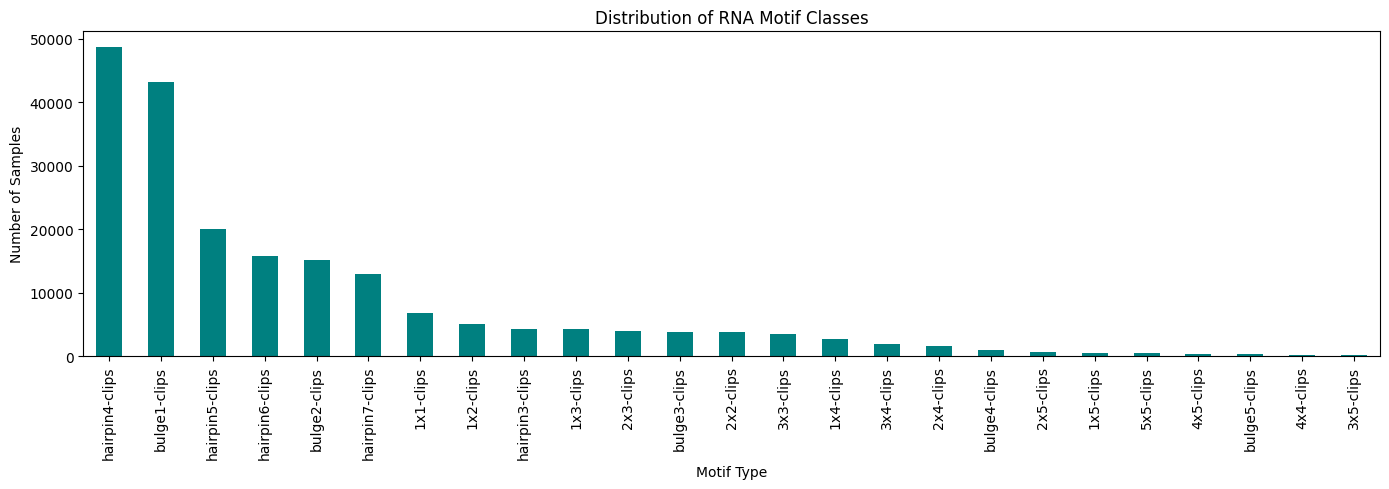

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
data["Label"].value_counts().plot(kind="bar", color="teal")
plt.title("Distribution of RNA Motif Classes")
plt.xlabel("Motif Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

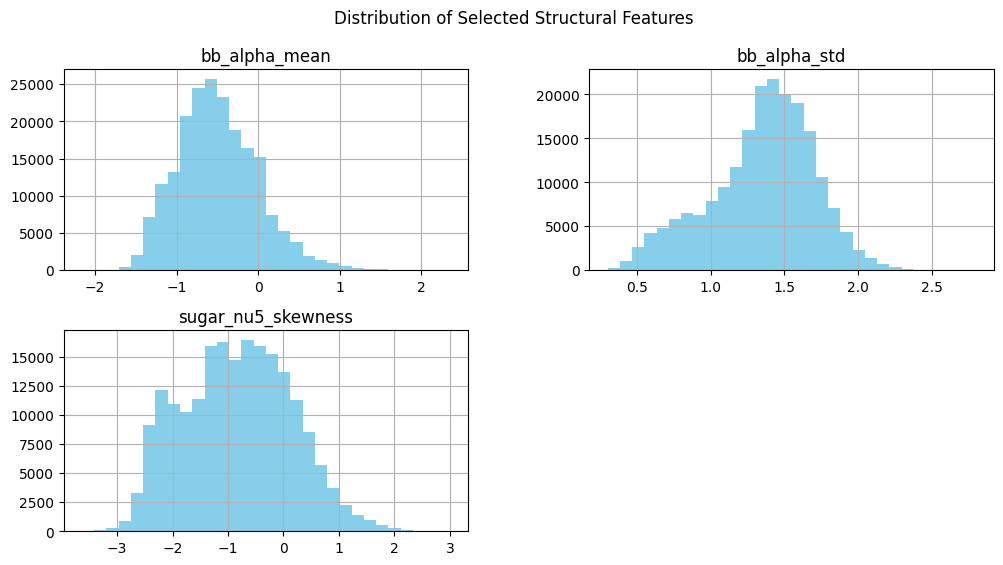

In [11]:
#histogram
data[['bb_alpha_mean', 'bb_alpha_std', 'sugar_nu5_skewness']].hist(
    figsize=(12,6), bins=30, color='skyblue'
)
plt.suptitle("Distribution of Selected Structural Features")
plt.show()

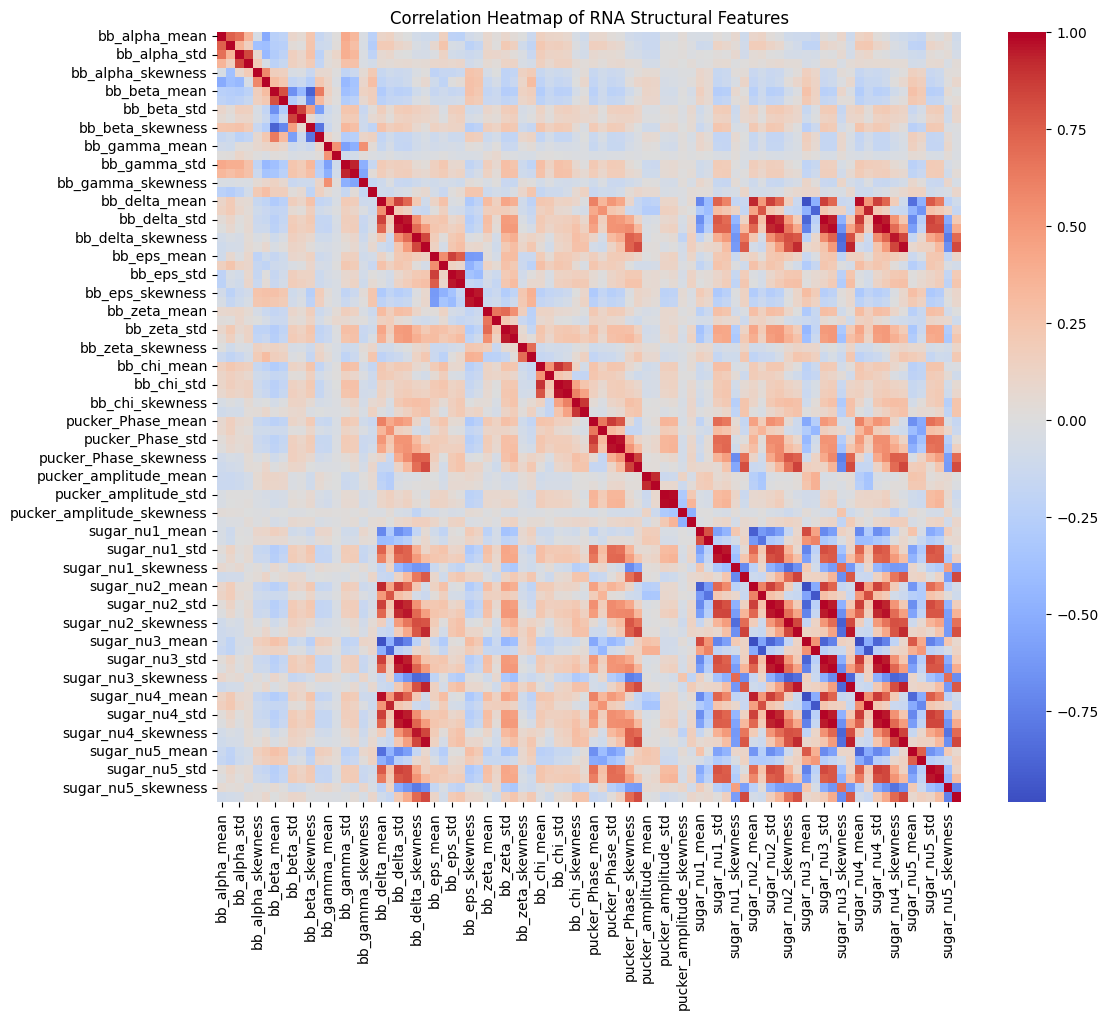

In [12]:
#heatmap
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(X_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of RNA Structural Features")
plt.show()

In [13]:
#data export
clean_df = X_df.copy()
clean_df["Label"] = y

clean_df.to_csv("preprocessed_dataset.csv", index=False)

In [14]:
#define terms x and y
data_clean = data.dropna()
X = data_clean.drop(columns=["Label", "Motifname", "Motifseq"])
y = data_clean["Label"]

print(X.shape)
print(y.shape)


(201375, 84)
(201375,)


In [15]:
#test/train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#scale after split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#Multinomial logistic regression softmax
#1. Standardize data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5790192427063936
                precision    recall  f1-score   support

     1x1-clips       0.37      0.64      0.47      1356
     1x2-clips       0.28      0.45      0.35      1007
     1x3-clips       0.40      0.58      0.48       801
     1x4-clips       0.41      0.59      0.48       528
     1x5-clips       0.34      0.82      0.48       117
     2x2-clips       0.35      0.48      0.40       733
     2x3-clips       0.44      0.34      0.38       764
     2x4-clips       0.53      0.62      0.57       339
     2x5-clips       0.32      0.60      0.42       126
     3x3-clips       0.45      0.26      0.33       737
     3x4-clips       0.46      0.49      0.47       410
     3x5-clips       0.08      0.67      0.15        21
     4x4-clips       0.07      0.54      0.12        28
     4x5-clips       0.17      0.41      0.24        70
     5x5-clips       0.58      0.63      0.60        89
  bulge1-clips       0.82      0.55      0.66      856

In [20]:
#train random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=40,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=40, n_jobs=-1,
                       random_state=42)

In [21]:
#evaluate random forest
import warnings
warnings.filterwarnings('ignore')
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.2348106765983861
                precision    recall  f1-score   support

     1x1-clips       0.00      0.00      0.00      1356
     1x2-clips       0.00      0.00      0.00      1007
     1x3-clips       0.00      0.00      0.00       801
     1x4-clips       0.00      0.00      0.00       528
     1x5-clips       0.00      0.00      0.00       117
     2x2-clips       0.00      0.00      0.00       733
     2x3-clips       0.00      0.00      0.00       764
     2x4-clips       0.00      0.00      0.00       339
     2x5-clips       0.00      0.00      0.00       126
     3x3-clips       0.00      0.00      0.00       737
     3x4-clips       0.00      0.00      0.00       410
     3x5-clips       0.00      0.00      0.00        21
     4x4-clips       0.00      0.00      0.00        28
     4x5-clips       0.00      0.00      0.00        70
     5x5-clips       0.00      0.00      0.00        89
  bulge1-clips       0.14      0.00      0.00      8561
  bu

In [22]:


data_clean = data.copy()

# Remove rows with missing values
data_clean = data_clean.dropna()

print("Cleaned dataset shape:", data_clean.shape)

Cleaned dataset shape: (201375, 87)


In [23]:
X = data_clean.drop(columns=["Label", "Motifname", "Motifseq"])
y = data_clean["Label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
#svm
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# train svm
from sklearn.svm import LinearSVC

svm = LinearSVC(C=0.1, max_iter=1000, dual=False, class_weight='balanced')

svm.fit(X_train_scaled, y_train)

LinearSVC(C=0.1, class_weight='balanced', dual=False)

In [26]:
y_pred_svm = svm.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.5651644941030416
                precision    recall  f1-score   support

     1x1-clips       0.41      0.53      0.47      1368
     1x2-clips       0.26      0.18      0.22       998
     1x3-clips       0.36      0.49      0.42       852
     1x4-clips       0.24      0.50      0.33       532
     1x5-clips       0.20      0.79      0.32       107
     2x2-clips       0.34      0.38      0.36       764
     2x3-clips       0.38      0.32      0.35       790
     2x4-clips       0.33      0.66      0.44       326
     2x5-clips       0.25      0.55      0.34       144
     3x3-clips       0.34      0.32      0.33       700
     3x4-clips       0.36      0.41      0.38       393
     3x5-clips       0.07      0.66      0.12        29
     4x4-clips       0.04      0.43      0.07        30
     4x5-clips       0.11      0.26      0.16        76
     5x5-clips       0.35      0.58      0.44        84
  bulge1-clips       0.75      0.72      0.74      8635
  bulge2-clips

In [28]:
#MLP neural network
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True
)


mlp.fit(X_train_scaled, y_train_enc)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=500,
              random_state=42)

In [30]:
#train model

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_scaled, y_train_enc)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64), max_iter=50,
              random_state=42)

In [31]:
#predict
y_pred_mlp = mlp.predict(X_test_scaled)

In [32]:
#evaluate
y_test_enc = le.transform(y_test)
y_pred_mlp = mlp.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("MLP Accuracy:", accuracy_score(y_test_enc, y_pred_mlp))

print(classification_report(
    y_test_enc,
    y_pred_mlp
))

MLP Accuracy: 0.9216635630043452
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1368
           1       0.91      0.82      0.86       998
           2       0.89      0.85      0.87       852
           3       0.86      0.80      0.83       532
           4       0.76      0.75      0.75       107
           5       0.81      0.88      0.84       764
           6       0.79      0.91      0.85       790
           7       0.80      0.83      0.82       326
           8       0.86      0.63      0.73       144
           9       0.87      0.91      0.89       700
          10       0.87      0.89      0.88       393
          11       0.87      0.69      0.77        29
          12       0.72      0.60      0.65        30
          13       0.76      0.66      0.70        76
          14       0.89      0.74      0.81        84
          15       0.97      0.97      0.97      8635
          16       0.89      0.93      0.91     

In [33]:
#Hyperparameter tuning
#Random forest
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, random_state=42, stratify=y_train
)


In [34]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_dist_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=2,
    scoring='f1_macro',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_small, y_small)

print("Best RF Params:", rf_search.best_params_)
print("Best CV Score:", rf_search.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best RF Params: {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV Score: 0.728330564081595


In [35]:
#evaluation metrics
#accuracy
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.20854127870887648


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encode
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [37]:
#PRECISION, RECALL, F1
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision (Macro):", precision_score(y_test, y_pred_rf, average='macro'))
print("Recall (Macro):", recall_score(y_test, y_pred_rf, average='macro'))
print("F1 Score (Macro):", f1_score(y_test, y_pred_rf, average='macro'))

print("F1 Score (Weighted):", f1_score(y_test, y_pred_rf, average='weighted'))

Precision (Macro): 0.9505694585162783
Recall (Macro): 0.857769802575895
F1 Score (Macro): 0.8977638557379747
F1 Score (Weighted): 0.9446843729300964


In [38]:
#full classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1356
           1       0.92      0.90      0.91      1007
           2       0.92      0.91      0.91       801
           3       0.94      0.88      0.90       528
           4       1.00      0.88      0.94       117
           5       0.93      0.89      0.91       733
           6       0.92      0.91      0.91       764
           7       0.93      0.86      0.89       339
           8       0.97      0.78      0.86       126
           9       0.93      0.93      0.93       737
          10       0.95      0.90      0.92       410
          11       1.00      0.76      0.86        21
          12       0.94      0.61      0.74        28
          13       0.98      0.79      0.87        70
          14       0.99      0.84      0.91        89
          15       0.94      0.99      0.97      8561
          16       0.90      0.95      0.93      3086
          17       0.93    

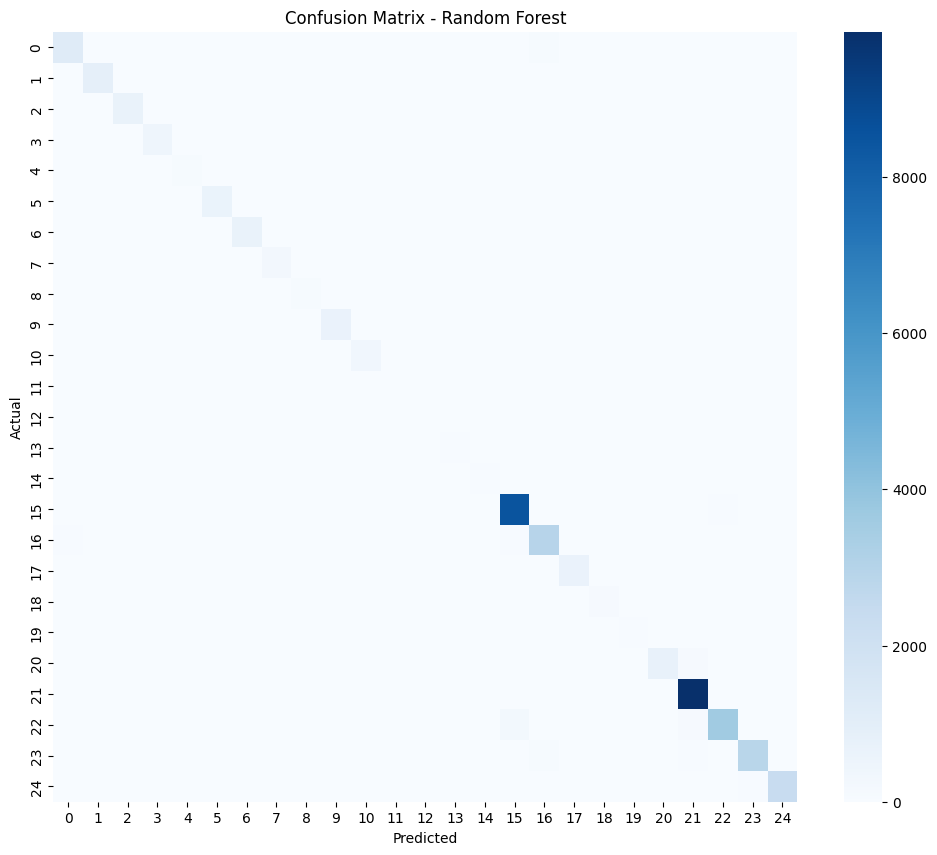

In [39]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
#ROC VS AUC
from sklearn.preprocessing import label_binarize

classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

In [41]:
best_rf = rf_search.best_estimator_
y_score = best_rf.predict_proba(X_test)

In [42]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')

print("ROC-AUC (Macro):", roc_auc)

ROC-AUC (Macro): nan


In [43]:
#learning curve random forest
# Reduce size for speed
import numpy as np
X_train_np = X_train.to_numpy()
y_train_np = np.array(y_train)



idx = np.random.choice(len(X_train_np), size=min(30000, len(X_train_np)), replace=False)

X_small = X_train_np[idx]
y_small = y_train_np[idx]

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_small,
    y_small,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

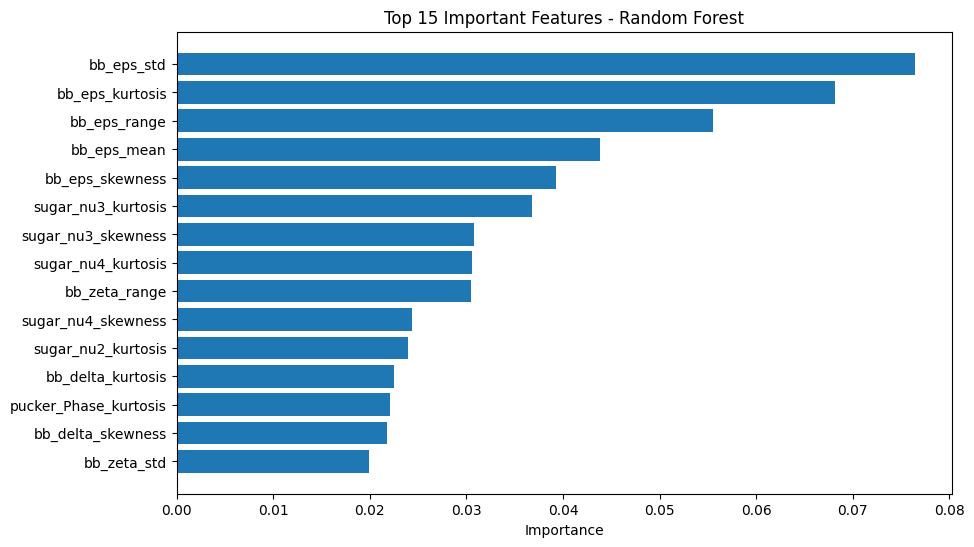

In [44]:

import pandas as pd

# 1. Get the importance values from your best model
importances = best_rf.feature_importances_

# 2. Create the DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:15][::-1],
         feature_importance["Importance"][:15][::-1])
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.show()

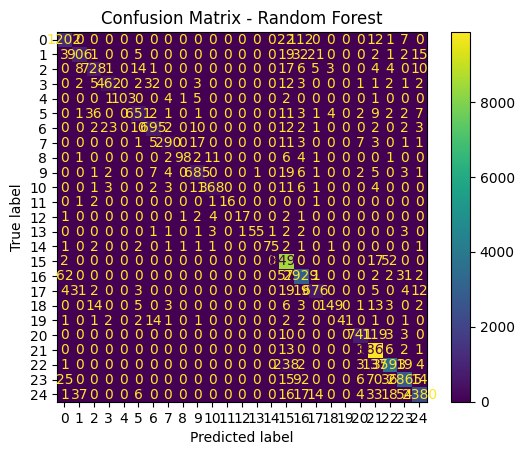

In [45]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


Explained variance: [0.2505308  0.14175658]


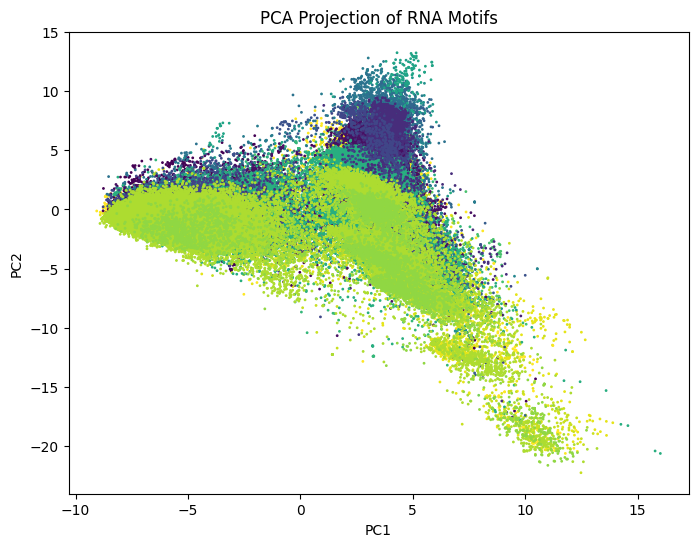

In [46]:
#PCA Dimensionality reduction

X = data.drop(columns=["Label", "Motifname", "Motifseq"])
y = data["Label"]

X = X.fillna(X.mean())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y.astype('category').cat.codes, cmap='viridis', s=1)
plt.title("PCA Projection of RNA Motifs")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [47]:
#web app for ml models
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 76.0 MB/s eta 0:00:00


In [48]:
import streamlit as st
import numpy as np
import pickle

st.title("RNA Motif Classification App")

import pickle

pickle.dump(rf, open("rf_model.pkl", "wb"))

# load model
model = pickle.load(open("rf_model.pkl", "rb"))

st.write("Enter feature values:")

# example input
features = []
for i in range(84):
    val = st.number_input(f"Feature {i}", value=0.0)
    features.append(val)

if st.button("Predict"):
    prediction = model.predict([features])
    st.write("Predicted Motif Class:", prediction[0])

2026-05-08 20:09:46.200 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:46.712 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-08 20:09:46.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:46.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:52.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:52.832 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:52.838 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 20:09:52.843 Thread 'MainThread': mi

In [49]:
#save app as file
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

st.title("RNA Motif Classification App")

# load model
model = pickle.load(open("rf_model.pkl", "rb"))

st.write("Enter feature values:")

features = []
for i in range(84):
    val = st.number_input(f"Feature {i}", value=0.0)
    features.append(val)

if st.button("Predict"):
    prediction = model.predict([features])
    st.write("Predicted Motif Class:", prediction[0])

Writing app.py


In [50]:
#download files
import pickle
pickle.dump(rf, open("rf_model.pkl", "wb"))